In [1]:
import sys

import pandas as pd

In [2]:

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
display(df.head())
df.info()
display(df.describe())
df.shape

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


(1200, 13)

In [3]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

depression_label
0    1169
1      31
Name: count, dtype: int64

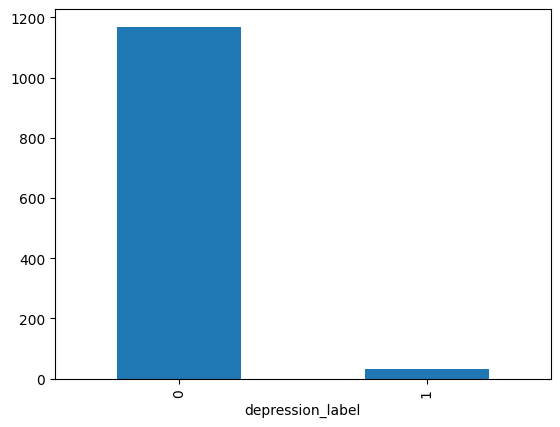

In [5]:

counts = df['depression_label'].value_counts()
counts.plot.bar()
counts

The dataset is severely imbalanced, with the positive class (depression_label=1) representing only 2.6% of samples. This limits the usefulness of accuracy as an evaluation metric, motivating our choice of F1 and ROC-AUC, and requires the use of stratified sampling and class-weighted models.

In [6]:
X = df.drop(columns=['depression_label'])   # 拿掉答案那欄,剩下都是線索
y = df['depression_label']                  # 只挑「答案」那欄
X.shape, y.shape                             # 確認形狀

((1200, 12), (1200,))

In [7]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head(10)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,1
5,19,7.4,4.4,2.4,2.63,0.6,3,5,7,0,0,0,0,0
6,18,2.5,6.4,2.4,2.63,0.7,2,2,5,0,1,0,1,0
7,16,4.0,4.2,0.5,2.40,1.3,6,10,5,1,0,0,1,0
8,19,3.3,5.0,2.1,2.04,0.9,1,10,9,0,0,1,0,0
9,15,1.9,4.9,1.5,3.77,1.1,1,1,4,1,0,1,0,0


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((960, 14), (240, 14))

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train.shape, X_test.shape

((960, 14), (240, 14))

In [10]:
from sklearn.linear_model import SGDClassifier

In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
)

def get_scores(classifier, X_test=X_test, y_test=y_test):
    y_pred = classifier.predict(X_test)
    y_score = classifier.decision_function(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_score)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print("F1:", f1, "\nROC AUC:", roc_auc, "\nAccuracy:", accuracy, "\nPrecision:", precision, "\nRecall:", recall)
    print(classification_report(y_test, y_pred))
    se = pd.Series([y_pred, y_score, accuracy, f1, roc_auc, precision, recall], index=['y_pred', 'y_score', 'Accuracy', 'F1', 'ROC AUC', 'Precision', 'Recall'])

    return se

def plot_confusion_matrix(y_pred, y_test=y_test):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('True'); plt.ylabel('Predicted'); plt.title('Confusion Matrix')
    plt.show()

metrics = ['Accuracy', 'F1', 'ROC-AUC', 'Precision', 'Recall']
def compare_multiple_scores(metrics, before_scores, after_scores_list, labels=None, title="Performance Comparison"):
    """
    compare GridSearchCV before and after scores for multiple models.
    
    metrics: list of str, labels, ex ['Accuracy','F1','ROC-AUC']
    before_scores: list of float, baseline scores for each metric, ex [0.92, 0.90, 0.93]
    after_scores_list: list of list, each after_scores, ex [[0.95,0.88,0.91],[0.96,0.89,0.92]]
    labels: list of str, each after_scores label, ex ['Model A','Model B']
    title: str, chart title
    """
    x = np.arange(len(metrics))
    width = 0.15  # each bar width
    
    plt.figure(figsize=(12,6))
    
    # baseline (Before)
    plt.bar(x - width, before_scores, width, label='Before', color='skyblue')
    
    # models After
    for i, scores in enumerate(after_scores_list):
        offset = (i+1) * width
        plt.bar(x + offset, scores, width, label=labels[i] if labels else f'After {i+1}')
        # at each bar, show the value
        for j, v in enumerate(scores):
            plt.text(j + offset, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    # baseline value labels
    for j, v in enumerate(before_scores):
        plt.text(j - width, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    plt.xticks(x, metrics)
    plt.ylabel('Score')
    plt.ylim(0, 1.1)
    plt.title(title)
    plt.legend()
    plt.show()

def plot_roc_curve(y_score, y_test=y_test):
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--', alpha=0.6)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve'); plt.legend(); plt.show()

F1: 0.625 
ROC AUC: 0.9928774928774928 
Accuracy: 0.975 
Precision: 0.5 
Recall: 0.8333333333333334
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       234
           1       0.50      0.83      0.62         6

    accuracy                           0.97       240
   macro avg       0.75      0.91      0.81       240
weighted avg       0.98      0.97      0.98       240



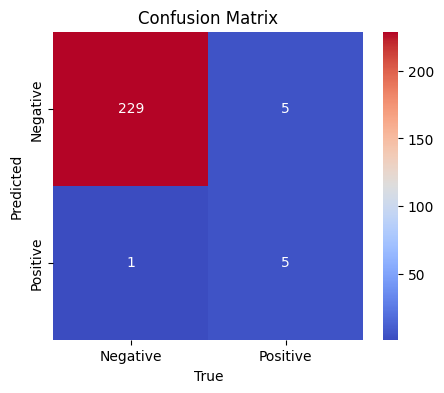

In [12]:
clf = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42, verbose=0,max_iter=1000, tol=1e-3)
clf.fit(X_train, y_train)

clfSeries = get_scores(clf)
plot_confusion_matrix(clfSeries['y_pred'])

Best params: {'alpha': 0.01, 'class_weight': 'balanced', 'loss': 'log_loss', 'penalty': 'elasticnet'}
Best CV F1: 0.8800000000000001
F1: 0.5714285714285714 
ROC AUC: 0.9943019943019943 
Accuracy: 0.9625 
Precision: 0.4 
Recall: 1.0
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



/Users/kuei/Projects/Mathematical-Concepts-Term-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/kuei/Projects/Mathematical-Concepts-Term-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/kuei/Projects/Mathematical-Concepts-Term-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/kuei/Projects/Mathematical-Concepts-Term-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: Convergenc

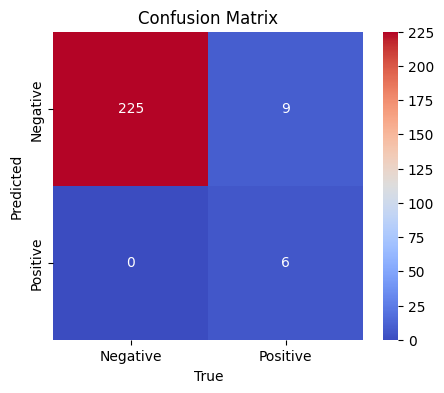

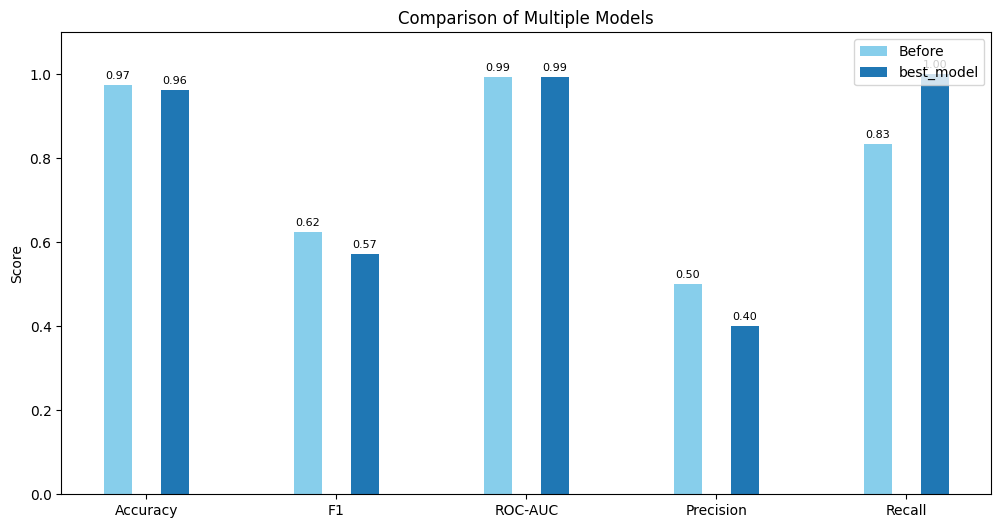

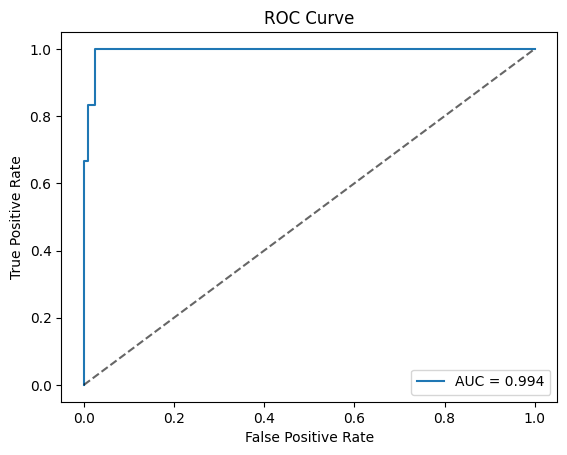

In [13]:
# model = SGDClassifier(
#     random_state=42, #確保每次運行結果一致
#     class_weight='balanced', #自動調整類別權重以處理不平衡數據
#     tol=1e-3, #設定收斂容忍度 
#             #   float or None, default=1e-3
#             #   The stopping criterion. If it is not None, 
#             #   training will stop when (loss > best_loss - tol) for n_iter_no_change consecutive epochs. 
#             #   Convergence is checked against the training loss or the validation loss depending on 
#             #   the early_stopping parameter. Values must be in the range [0.0, inf).
#     early_stopping=True, #啟用早停機制
#             # bool, default=False
#             # Whether to use early stopping to terminate training when validation score is not improving. 
#             # If set to True, it will automatically set aside 10% of training data as validation and terminate training when validation score is not improving by at least tol for n_iter_no_change consecutive epochs. 
#             # Only effective when solver='sgd' or 'adam'.
#     n_iter_no_change=5, #設定早停的耐心值
#             # int, default=5
#             # Number of iterations with no improvement to wait before early stopping.
#     verbose=0 # 0: no output, 1: output progress and performance, 2: output progress only
# )

param_grid = {
    'loss': ['log_loss', 'hinge', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [1e-4, 1e-3, 1e-2],
    # 'learning_rate': ['optimal', 'invscaling', 'adaptive'],
    # 'eta0': [0.001, 0.01],
    # 'max_iter': [5, 10, 30, 50, 100, 500 ,1000],
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #使用分層K折交叉驗證來確保每個折中類別分佈的一致性，從而獲得更可靠的模型評估結果

grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring='recall', #使用F1分數作為評估指標，因為它在處理不平衡數據時能夠更好地平衡精確率和召回率
    cv=cv,
    n_jobs=-1, #使用所有可用的CPU核心來加速網格搜索過程
    verbose=0 #設置詳細程度為2以獲得每個參數組合的進度更新，從而更好地監控網格搜索過程
)

grid.fit(X_train, y_train) #在訓練數據上執行網格搜索以找到最佳的超參數組合，從而提高模型的性能和泛化能力


print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_model = grid.best_estimator_
best_model_Series = get_scores(best_model)
plot_confusion_matrix(best_model_Series['y_pred'])

before = [clfSeries['Accuracy'], clfSeries['F1'], clfSeries['ROC AUC'], clfSeries['Precision'], clfSeries['Recall']]
after_list = [
    [best_model_Series['Accuracy'], best_model_Series['F1'], best_model_Series['ROC AUC'], best_model_Series['Precision'], best_model_Series['Recall']]
]
labels = ['best_model']

compare_multiple_scores(metrics, before, after_list, labels, title="Comparison of Multiple Models")

plot_roc_curve(best_model.decision_function(X_test))

/Users/kuei/Projects/Mathematical-Concepts-Term-project/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=14. All the features will be returned.
  warnings.warn(
/Users/kuei/Projects/Mathematical-Concepts-Term-project/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=14. All the features will be returned.
  warnings.warn(
/Users/kuei/Projects/Mathematical-Concepts-Term-project/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=14. All the features will be returned.
  warnings.warn(
/Users/kuei/Projects/Mathematical-Concepts-Term-project/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=14. All the features will be returned.
  warnings.warn(
/Users/k

Best params: {'clf__class_weight': 'balanced', 'select__k': 6}
F1: 0.5454545454545454 
ROC AUC: 0.9943019943019944 
Accuracy: 0.9583333333333334 
Precision: 0.375 
Recall: 1.0
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.38      1.00      0.55         6

    accuracy                           0.96       240
   macro avg       0.69      0.98      0.76       240
weighted avg       0.98      0.96      0.97       240



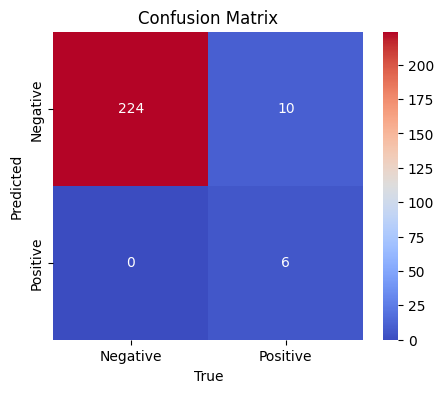

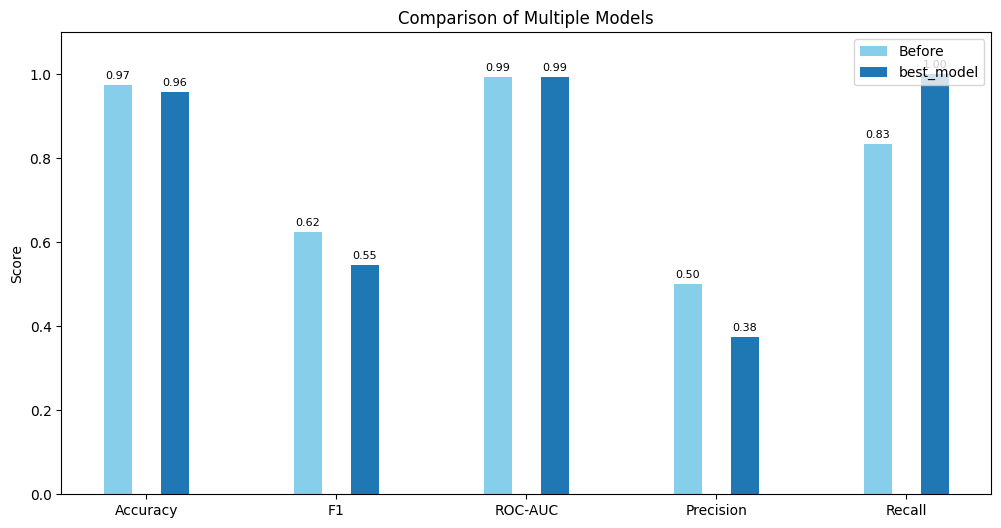

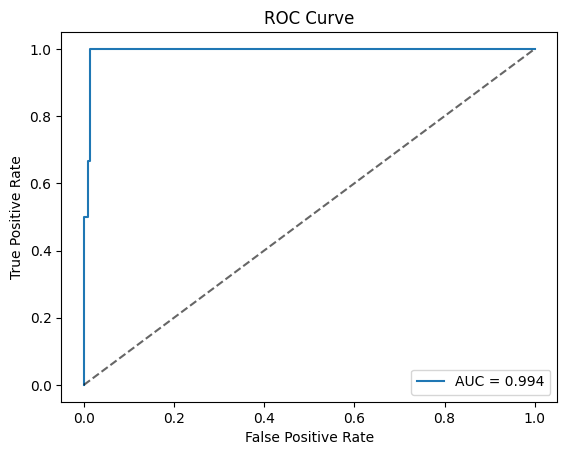

Selected features: Index(['daily_social_media_hours', 'sleep_hours', 'academic_performance',
       'stress_level', 'anxiety_level', 'gender_male'],
      dtype='str')
    rank_test_score  param_select__k  mean_test_score  std_test_score
11                1                6             0.96        0.080000
19                2               15             0.92        0.160000
15                2               10             0.92        0.160000
10                2                5             0.92        0.160000
13                5                8             0.88        0.097980
12                6                7             0.84        0.233238
18                6               14             0.84        0.149666
14                8                9             0.84        0.149666
17                9               13             0.76        0.149666
16                9               12             0.76        0.195959
9                11               15             0.56        0

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('select', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(solver='saga', max_iter=1000))
])

param_grid_pipe = {
    'select__k': [5, 6, 7, 8, 9, 10, 12, 13, 14, 15],
    # 'clf__C': [0.01, 0.1, 1, 10],
    # 'clf__penalty': ['l2', 'l1', 'elasticnet'],
    # 'clf__l1_ratio': [0.0, 0.5, 1.0],
    'clf__class_weight': [None, 'balanced']
}

#  param_grid_pipe, cv=5, scoring='accuracy',
grid_pipe = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid_pipe,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=0 )

grid_pipe.fit(X_train, y_train)

print("Best params:", grid_pipe.best_params_)
best_model = grid_pipe.best_estimator_
best_model_Series = get_scores(best_model)
plot_confusion_matrix(best_model_Series['y_pred'])

before = [clfSeries['Accuracy'], clfSeries['F1'], clfSeries['ROC AUC'], clfSeries['Precision'], clfSeries['Recall']]
after_list = [
    [best_model_Series['Accuracy'], best_model_Series['F1'], best_model_Series['ROC AUC'], best_model_Series['Precision'], best_model_Series['Recall']]
]
labels = ['best_model']

compare_multiple_scores(metrics, before, after_list, labels, title="Comparison of Multiple Models")

plot_roc_curve(best_model.decision_function(X_test))


best_selector = grid_pipe.best_estimator_.named_steps['select']
mask = best_selector.get_support()   # True/False mask
selected_features = X.columns[mask]
print("Selected features:", selected_features)

results = pd.DataFrame(grid_pipe.cv_results_)
print(results[['rank_test_score', 'param_select__k','mean_test_score','std_test_score']].sort_values('rank_test_score'))

Baseline recall with all features: 1.0000

Top 10 drop-feature results:
                dropped_feature  recall
                            age     1.0
       daily_social_media_hours     1.0
       screen_time_before_sleep     1.0
              physical_activity     1.0
                   stress_level     1.0
                addiction_level     1.0
       platform_usage_Instagram     1.0
          platform_usage_TikTok     1.0
   social_interaction_level_low     1.0
social_interaction_level_medium     1.0

Worst 10 drop-feature results:
                dropped_feature   recall
                   stress_level 1.000000
                addiction_level 1.000000
       platform_usage_Instagram 1.000000
          platform_usage_TikTok 1.000000
   social_interaction_level_low 1.000000
social_interaction_level_medium 1.000000
                    sleep_hours 0.833333
           academic_performance 0.833333
                  anxiety_level 0.833333
                    gender_male 0.833333

Coun

<Figure size 1200x382 with 0 Axes>

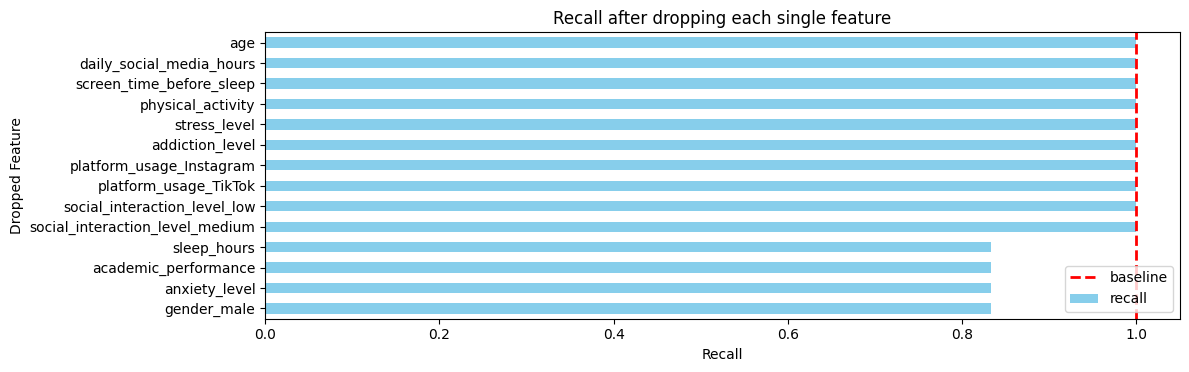

<Figure size 1200x382 with 0 Axes>

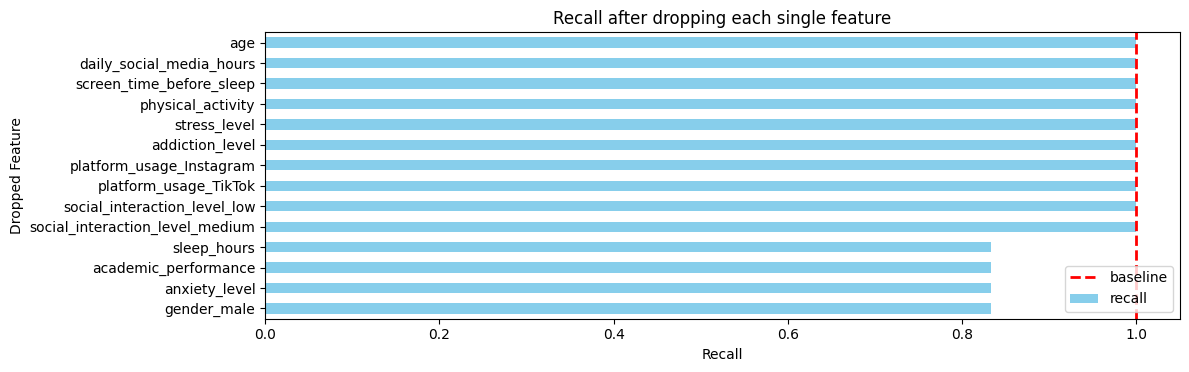

<Figure size 1200x800 with 0 Axes>

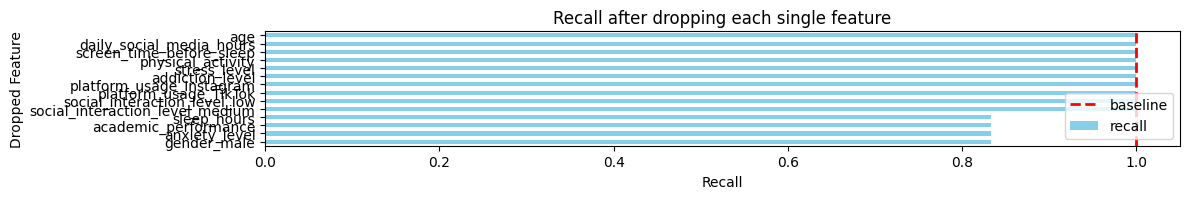

In [16]:
feature_names = X.columns.tolist()
results = []

# 先算 full-feature baseline recall
baseline_acc = recall_score(y_test, best_model.predict(X_test))
print(f"Baseline recall with all features: {baseline_acc:.4f}\n")

for drop_feature in feature_names:
    keep_features = [c for c in feature_names if c != drop_feature]
    X_reduced = X[keep_features]

    X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
        X_reduced, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler_red = StandardScaler()
    X_train_red = scaler_red.fit_transform(X_train_red)
    X_test_red = scaler_red.transform(X_test_red)

    model_red = SGDClassifier(random_state=42, verbose=0, max_iter=1000, tol=1e-3, **grid.best_params_)

    model_red.fit(X_train_red, y_train_red)

    y_pred_red = model_red.predict(X_test_red)
    acc_red = recall_score(y_test_red, y_pred_red)
    results.append((drop_feature, acc_red))

result_df = pd.DataFrame(results, columns=['dropped_feature', 'recall'])
result_df = result_df.sort_values(by='recall', ascending=False).reset_index(drop=True)

print('Top 10 drop-feature results:')
print(result_df.head(10).to_string(index=False))
print('\nWorst 10 drop-feature results:')
print(result_df.tail(10).to_string(index=False))
print(f"\nCount of drop-feature models with recall >= baseline: {sum(result_df['recall'] >= baseline_acc)} / {len(result_df)}")

# 繪製 bar chart
plt.figure(figsize=(12, len(result_df) * 0.13 + 2))
ax = result_df.plot.barh(
    x='dropped_feature',
    y='recall',
    legend=False,
    color='skyblue',
    figsize=(12, len(result_df) * 0.13 + 2)
)
ax.axvline(baseline_acc, color='red', linestyle='--', linewidth=2, label='baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Dropped Feature')
ax.set_title('Recall after dropping each single feature')
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 繪製 bar chart
plt.figure(figsize=(12, len(result_df) * 0.13 + 2))
ax = result_df.plot.barh(
    x='dropped_feature',
    y='recall',
    legend=False,
    color='skyblue',
    figsize=(12, len(result_df) * 0.13 + 2)
)
ax.axvline(baseline_acc, color='red', linestyle='--', linewidth=2, label='baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Dropped Feature')
ax.set_title('Recall after dropping each single feature')
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 繪製 bar chart
plt.figure(figsize=(12, 8))
ax = result_df.plot.barh(
    x='dropped_feature',
    y='recall',
    legend=False,
    color='skyblue',
    figsize=(12, len(result_df) * 0.15)
)
ax.axvline(baseline_acc, color='red', linestyle='--', linewidth=2, label='baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Dropped Feature')
ax.set_title('Recall after dropping each single feature')
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()